<h1 style = "color:Darkblue"><b>Medical Cost Prediction System </b></h1>

* This project demonstrates how machine learning can be effectively used 
in healthcare to estimate medical costs and support better financial and treatment planning.

In [1]:
pip install mysql-connector-python pandas

In [2]:
#SQL Connectect Database
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="12345",
    database="Medical_Cost_Prediction"
)

print("Connected Successfully")

Connected Successfully


<h2> Ignore Warning</h2>

In [3]:
import warnings
warnings.filterwarnings("ignore")

<h2> Show all Table</h2>

In [4]:
import pandas as pd
query = "SELECT * FROM hospital_visit"

hospital_visit = pd.read_sql(query, conn)
hospital_visit

,Visit_id,Patient_id,Hospital_id,Visit_date,Visit_reason
0,VIS0001,PAT0202,HOSP0691,2023-05-20,Injury
1,VIS0002,PAT0214,HOSP0952,2022-01-19,Diabetes Check
2,VIS0003,PAT0606,HOSP0080,2023-03-16,Injury
3,VIS0004,PAT0478,HOSP0057,2022-08-18,Heart Pain
4,VIS0005,PAT0508,HOSP0366,2022-05-10,Fever
...,...,...,...,...,...
995,VIS0996,PAT0721,HOSP0454,2022-10-14,Checkup
996,VIS0997,PAT0784,HOSP0882,2023-10-03,Heart Pain
997,VIS0998,PAT0144,HOSP0742,2023-05-27,Heart Pain
998,VIS0999,PAT0251,HOSP0166,2023-02-09,Fever


In [5]:

query = "SELECT * FROM hospitals"

hospital = pd.read_sql(query, conn)
hospital

,Hospital_id,Hospital_name,City,State,Hospital_type
0,HOSP0001,Hospital_1,Ujjain,Madhya Pradesh,Government
1,HOSP0002,Hospital_2,Jabalpur,Madhya Pradesh,Private
2,HOSP0003,Hospital_3,Jabalpur,Madhya Pradesh,Private
3,HOSP0004,Hospital_4,Ujjain,Madhya Pradesh,Government
4,HOSP0005,Hospital_5,Jabalpur,Madhya Pradesh,Government
...,...,...,...,...,...
995,HOSP0996,Hospital_996,Indore,Madhya Pradesh,Private
996,HOSP0997,Hospital_997,Indore,Madhya Pradesh,Government
997,HOSP0998,Hospital_998,Ujjain,Madhya Pradesh,Government
998,HOSP0999,Hospital_999,Ujjain,Madhya Pradesh,Private


In [6]:
query = "SELECT * FROM patients"

patient = pd.read_sql(query, conn)
patient

,Patient_id,First_name,Last_name,Gender,Date,City,State
0,PAT0001,Karan,sharma,Female,1992-04-06,Jabalpur,Madhya Pradesh
1,PAT0002,Neha,gupta,Female,1994-01-05,Ujjain,Madhya Pradesh
2,PAT0003,Pooja,singh,Male,1988-02-26,Bhopal,Madhya Pradesh
3,PAT0004,Rohit,singh,Male,1974-11-30,Indore,Madhya Pradesh
4,PAT0005,Karan,patel,Male,1980-03-09,Gwalior,Madhya Pradesh
...,...,...,...,...,...,...,...
995,PAT0996,Simran,yadav,Female,1980-10-22,Not Available,Madhya Pradesh
996,PAT0997,Simran,joshi,Male,1974-04-07,Indore,Madhya Pradesh
997,PAT0998,Pooja,patel,Female,1996-07-26,Not Available,Madhya Pradesh
998,PAT0999,Priya,verma,Male,1981-05-17,Not Available,Madhya Pradesh


In [12]:
query = "SELECT * FROM lifestyle"

lifestyle = pd.read_sql(query, conn)
lifestyle

,lifestyle_id,Patient_id,smoking_status,alcohol_consumption,Bmi,exercise_frequency
0,LIFE0001,PAT0001,Yes,No,26.5,Rare
1,LIFE0002,PAT0002,Yes,Yes,23.8,Weekly
2,LIFE0003,PAT0003,Yes,Yes,22.1,Rare
3,LIFE0004,PAT0004,Yes,No,24.8,Rare
4,LIFE0005,PAT0005,No,Yes,18.3,Weekly
...,...,...,...,...,...,...
995,LIFE0996,PAT0996,No,No,28.6,Monthly
996,LIFE0997,PAT0997,Yes,Yes,25.0,Monthly
997,LIFE0998,PAT0998,Yes,Yes,22.3,Monthly
998,LIFE0999,PAT0999,Yes,No,32.6,Monthly


In [13]:
query = "SELECT * FROM lab_test"

lab = pd.read_sql(query, conn)
lab

,Test_id,Visit_id,Test_name,Test_result,Test_cost
0,LAB0001,VIS0001,ECG,Negative,1018
1,LAB0002,VIS0002,ECG,Normal,2624
2,LAB0003,VIS0003,Blood Test,Negative,837
3,LAB0004,VIS0004,ECG,Negative,2313
4,LAB0005,VIS0005,Blood Test,Abnormal,2369
...,...,...,...,...,...
995,LAB0996,VIS0996,TSH,Negative,2260
996,LAB0997,VIS0997,ECG,Low,1224
997,LAB0998,VIS0998,TSH,Positive,1844
998,LAB0999,VIS0999,Blood Test,Positive,2317


In [14]:
query = "SELECT * FROM medical_history"

medical_h = pd.read_sql(query, conn)
medical_h

,History_id,Patient_id,Chronic_disease,Diagnosis_date,Allergies
0,HIS0001,PAT0001,Thyroid,2019-07-23,Peanuts
1,HIS0002,PAT0002,Unknown,2017-02-05,No Allergy
2,HIS0003,PAT0003,Asthma,2018-05-06,Peanuts
3,HIS0004,PAT0004,Thyroid,2019-03-04,Penicillin
4,HIS0005,PAT0005,Thyroid,2022-11-28,No Allergy
...,...,...,...,...,...
995,HIS0996,PAT0996,Thyroid,2021-11-17,Peanuts
996,HIS0997,PAT0997,Thyroid,2019-01-14,No Allergy
997,HIS0998,PAT0998,Unknown,2018-12-15,Dust
998,HIS0999,PAT0999,Thyroid,2018-05-11,Dust


In [15]:
query = "SELECT * FROM medical_billing"

medical_b = pd.read_sql(query, conn)
medical_b

,Bill_id,Visit_id,Total_amount,Insurance_covered,Out_of_pocket,Payment_status
0,BILL0001,VIS0001,18381,7427,19136,Pending
1,BILL0002,VIS0002,18893,6603,3978,Pending
2,BILL0003,VIS0003,33130,26630,5332,Paid
3,BILL0004,VIS0004,35415,20468,4013,Pending
4,BILL0005,VIS0005,24143,2899,16089,Paid
...,...,...,...,...,...,...
995,BILL0996,VIS0996,21737,18917,1775,Paid
996,BILL0997,VIS0997,7318,19640,18119,Pending
997,BILL0998,VIS0998,30314,20041,18870,Pending
998,BILL0999,VIS0999,40287,27728,17779,Pending


In [16]:
query = "SELECT * FROM insurance"

insurance = pd.read_sql(query, conn)
insurance

,Insurance_id,Patient_id,Insurance_provider,Policy_number,Coverage_amount,Policy_start_date,Policy_end_date
0,INS0001,PAT0001,Star Health,POL0001,444912,2021-10-13,2026-11-03
1,INS0002,PAT0002,Bajaj Allianz,POL0002,687073,2021-08-27,2027-12-05
2,INS0003,PAT0003,Bajaj Allianz,POL0003,700338,2022-01-20,2026-02-24
3,INS0004,PAT0004,Bajaj Allianz,POL0004,647026,2020-07-06,2025-11-29
4,INS0005,PAT0005,HDFC Ergo,POL0005,174231,2020-03-22,2025-05-07
...,...,...,...,...,...,...,...
995,INS0996,PAT0996,ICICI Lombard,POL0996,334898,2019-04-17,2024-06-07
996,INS0997,PAT0997,Bajaj Allianz,POL0997,561122,2022-11-01,2027-02-14
997,INS0998,PAT0998,Bajaj Allianz,POL0998,775025,2022-11-25,2026-10-28
998,INS0999,PAT0999,Star Health,POL0999,170246,2018-02-19,2025-09-08


In [17]:
query = "SELECT * FROM Prescription"

pre = pd.read_sql(query, conn)
pre

,Prescription_id,Visit_id,Medicine_name,Dosage,Duration_days
0,PRE0001,VIS0001,Paracetamol,50mcg,12
1,PRE0002,VIS0002,Thyroxine,500mg,54
2,PRE0003,VIS0003,Vitamin D,650mg,14
3,PRE0004,VIS0004,Vitamin D,650mg,74
4,PRE0005,VIS0280,Thyroxine,1000IU,64
...,...,...,...,...,...
592,PRE0596,VIS0596,Paracetamol,75mg,24
593,PRE0597,VIS0597,Paracetamol,500mg,8
594,PRE0598,VIS0280,Thyroxine,650mg,22
595,PRE0599,VIS0599,Vitamin D,50mcg,87


# ALL Table Merge 

In [18]:
lab_agg = lab.groupby("Visit_id").agg({
    "Test_cost": "sum"                   #Test cost ka sum
}).reset_index()

In [19]:
#df.drop(0, axis=0, inplace=True)
import pandas as pd
dt = pd.merge(patient, hospital_visit, on="Patient_id", how="inner")            #Patient+hspotal_visit
dt = pd.merge(dt, medical_b, on="Visit_id", how="inner")                        #medical_billing
dt = pd.merge(dt, hospital, on="Hospital_id", how="inner")                      #Lifestyle
dt = pd.merge(dt, lifestyle, on="Patient_id", how="inner")                      #Insurance Table
dt = pd.merge(dt, insurance, on="Patient_id", how="inner")                      #Patient
dt = pd.merge(dt, medical_h, on="Patient_id", how="inner")                      #Medical_history
dt = pd.merge(dt, lab_agg, on="Visit_id", how="inner")                          # Test cost ka sum

In [20]:
dt

,Patient_id,First_name,Last_name,Gender,Date,City_x,State_x,Visit_id,Hospital_id,Visit_date,...,Insurance_provider,Policy_number,Coverage_amount,Policy_start_date,Policy_end_date,History_id,Chronic_disease,Diagnosis_date,Allergies,Test_cost
0,PAT0001,Karan,sharma,Female,1992-04-06,Jabalpur,Madhya Pradesh,VIS0134,HOSP0402,2022-08-19,...,Star Health,POL0001,444912,2021-10-13,2026-11-03,HIS0001,Thyroid,2019-07-23,Peanuts,643
1,PAT0001,Karan,sharma,Female,1992-04-06,Jabalpur,Madhya Pradesh,VIS0265,HOSP0003,2022-11-06,...,Star Health,POL0001,444912,2021-10-13,2026-11-03,HIS0001,Thyroid,2019-07-23,Peanuts,2536
2,PAT0005,Karan,patel,Male,1980-03-09,Gwalior,Madhya Pradesh,VIS0655,HOSP0346,2023-06-01,...,HDFC Ergo,POL0005,174231,2020-03-22,2025-05-07,HIS0005,Thyroid,2022-11-28,No Allergy,1865
3,PAT0006,Simran,gupta,Male,1981-04-28,Indore,Madhya Pradesh,VIS0799,HOSP0638,2023-06-10,...,Star Health,POL0006,173606,2018-12-29,2025-07-12,HIS0006,Diabetes,2020-03-22,Peanuts,1028
4,PAT0006,Simran,gupta,Male,1981-04-28,Indore,Madhya Pradesh,VIS0961,HOSP0291,2022-05-15,...,Star Health,POL0006,173606,2018-12-29,2025-07-12,HIS0006,Diabetes,2020-03-22,Peanuts,1795
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,PAT0994,Pooja,mishra,Male,2002-07-29,Not Available,Madhya Pradesh,VIS0369,HOSP0877,2023-02-17,...,HDFC Ergo,POL0994,158047,2022-05-03,2027-09-17,HIS0994,Asthma,2017-10-28,Dust,1436
996,PAT0994,Pooja,mishra,Male,2002-07-29,Not Available,Madhya Pradesh,VIS0617,HOSP0392,2022-04-22,...,HDFC Ergo,POL0994,158047,2022-05-03,2027-09-17,HIS0994,Asthma,2017-10-28,Dust,1050
997,PAT0994,Pooja,mishra,Male,2002-07-29,Not Available,Madhya Pradesh,VIS0792,HOSP0300,2022-10-17,...,HDFC Ergo,POL0994,158047,2022-05-03,2027-09-17,HIS0994,Asthma,2017-10-28,Dust,924
998,PAT0997,Simran,joshi,Male,1974-04-07,Indore,Madhya Pradesh,VIS0882,HOSP0319,2023-12-06,...,Bajaj Allianz,POL0997,561122,2022-11-01,2027-02-14,HIS0997,Thyroid,2019-01-14,No Allergy,2348


In [21]:
pre['Medicine_name'].nunique()

11

<h1 style = 'color: red"> EDA </h1>

<h1 style = "color:red" >Exploratory Data Analysis (EDA) </h1>

<h3> Top 5 Row of Data</h3>

In [22]:
dt.head()

,Patient_id,First_name,Last_name,Gender,Date,City_x,State_x,Visit_id,Hospital_id,Visit_date,...,Insurance_provider,Policy_number,Coverage_amount,Policy_start_date,Policy_end_date,History_id,Chronic_disease,Diagnosis_date,Allergies,Test_cost
0,PAT0001,Karan,sharma,Female,1992-04-06,Jabalpur,Madhya Pradesh,VIS0134,HOSP0402,2022-08-19,...,Star Health,POL0001,444912,2021-10-13,2026-11-03,HIS0001,Thyroid,2019-07-23,Peanuts,643
1,PAT0001,Karan,sharma,Female,1992-04-06,Jabalpur,Madhya Pradesh,VIS0265,HOSP0003,2022-11-06,...,Star Health,POL0001,444912,2021-10-13,2026-11-03,HIS0001,Thyroid,2019-07-23,Peanuts,2536
2,PAT0005,Karan,patel,Male,1980-03-09,Gwalior,Madhya Pradesh,VIS0655,HOSP0346,2023-06-01,...,HDFC Ergo,POL0005,174231,2020-03-22,2025-05-07,HIS0005,Thyroid,2022-11-28,No Allergy,1865
3,PAT0006,Simran,gupta,Male,1981-04-28,Indore,Madhya Pradesh,VIS0799,HOSP0638,2023-06-10,...,Star Health,POL0006,173606,2018-12-29,2025-07-12,HIS0006,Diabetes,2020-03-22,Peanuts,1028
4,PAT0006,Simran,gupta,Male,1981-04-28,Indore,Madhya Pradesh,VIS0961,HOSP0291,2022-05-15,...,Star Health,POL0006,173606,2018-12-29,2025-07-12,HIS0006,Diabetes,2020-03-22,Peanuts,1795


 <h3> Display Column Names & Datatype & Memory Usage </h3>

In [23]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_id           1000 non-null   object 
 1   First_name           1000 non-null   object 
 2   Last_name            1000 non-null   object 
 3   Gender               1000 non-null   object 
 4   Date                 1000 non-null   object 
 5   City_x               1000 non-null   object 
 6   State_x              1000 non-null   object 
 7   Visit_id             1000 non-null   object 
 8   Hospital_id          1000 non-null   object 
 9   Visit_date           1000 non-null   object 
 10  Visit_reason         1000 non-null   object 
 11  Bill_id              1000 non-null   object 
 12  Total_amount         1000 non-null   int64  
 13  Insurance_covered    1000 non-null   int64  
 14  Out_of_pocket        1000 non-null   int64  
 15  Payment_status       1000 non-null   ob

 <h3> Display Total Number of Rows & Columns </h3>

In [93]:
print("Row",dt.shape[0])
print("Column",dt.shape[1])

Row 1000
Column 18


<h3> Display Only The Name of Columns </h3>

In [25]:
dt.columns

Index(['Patient_id', 'First_name', 'Last_name', 'Gender', 'Date', 'City_x',
       'State_x', 'Visit_id', 'Hospital_id', 'Visit_date', 'Visit_reason',
       'Bill_id', 'Total_amount', 'Insurance_covered', 'Out_of_pocket',
       'Payment_status', 'Hospital_name', 'City_y', 'State_y', 'Hospital_type',
       'lifestyle_id', 'smoking_status', 'alcohol_consumption', 'Bmi',
       'exercise_frequency', 'Insurance_id', 'Insurance_provider',
       'Policy_number', 'Coverage_amount', 'Policy_start_date',
       'Policy_end_date', 'History_id', 'Chronic_disease', 'Diagnosis_date',
       'Allergies', 'Test_cost'],
      dtype='object')

<h3> Display The Name of Those Columns Which Have Object Data Type</h3>

In [95]:
dt.select_dtypes(include=object).columns

Index(['Gender', 'Visit_reason', 'Payment_status', 'Hospital_type',
       'smoking_status', 'alcohol_consumption', 'exercise_frequency',
       'Chronic_disease', 'Allergies'],
      dtype='object')

In [96]:
dt.select_dtypes(include=object).columns.nunique()                 # Number of Object data type

9

<h3> Check Whether Null Value Exists in Dataset</h3>

In [97]:
dt.isnull().values.any()

np.False_

<h3>  Display Mean, Count, Std, Min, Max of Dataset</h3>

In [29]:
dt.describe().loc[['min','max','mean','count']]

,Total_amount,Insurance_covered,Out_of_pocket,Bmi,Coverage_amount,Test_cost
min,5084.000,2085.000,1018.000,18.0000,101132.000,501.00
max,49929.000,29981.000,19978.000,35.0000,997748.000,2999.00
mean,27438.545,15924.502,10482.006,26.2402,535083.813,1741.25
count,1000.000,1000.000,1000.000,1000.0000,1000.000,1000.00


<h3> Check Null Value</h3>

In [30]:
dt.isnull().sum()

Patient_id             0
First_name             0
Last_name              0
Gender                 0
Date                   0
City_x                 0
State_x                0
Visit_id               0
Hospital_id            0
Visit_date             0
Visit_reason           0
Bill_id                0
Total_amount           0
Insurance_covered      0
Out_of_pocket          0
Payment_status         0
Hospital_name          0
City_y                 0
State_y                0
Hospital_type          0
lifestyle_id           0
smoking_status         0
alcohol_consumption    0
Bmi                    0
exercise_frequency     0
Insurance_id           0
Insurance_provider     0
Policy_number          0
Coverage_amount        0
Policy_start_date      0
Policy_end_date        0
History_id             0
Chronic_disease        0
Diagnosis_date         0
Allergies              0
Test_cost              0
dtype: int64

<h3> Handle Missing Value</h3>

In [31]:
dt.dropna()

,Patient_id,First_name,Last_name,Gender,Date,City_x,State_x,Visit_id,Hospital_id,Visit_date,...,Insurance_provider,Policy_number,Coverage_amount,Policy_start_date,Policy_end_date,History_id,Chronic_disease,Diagnosis_date,Allergies,Test_cost
0,PAT0001,Karan,sharma,Female,1992-04-06,Jabalpur,Madhya Pradesh,VIS0134,HOSP0402,2022-08-19,...,Star Health,POL0001,444912,2021-10-13,2026-11-03,HIS0001,Thyroid,2019-07-23,Peanuts,643
1,PAT0001,Karan,sharma,Female,1992-04-06,Jabalpur,Madhya Pradesh,VIS0265,HOSP0003,2022-11-06,...,Star Health,POL0001,444912,2021-10-13,2026-11-03,HIS0001,Thyroid,2019-07-23,Peanuts,2536
2,PAT0005,Karan,patel,Male,1980-03-09,Gwalior,Madhya Pradesh,VIS0655,HOSP0346,2023-06-01,...,HDFC Ergo,POL0005,174231,2020-03-22,2025-05-07,HIS0005,Thyroid,2022-11-28,No Allergy,1865
3,PAT0006,Simran,gupta,Male,1981-04-28,Indore,Madhya Pradesh,VIS0799,HOSP0638,2023-06-10,...,Star Health,POL0006,173606,2018-12-29,2025-07-12,HIS0006,Diabetes,2020-03-22,Peanuts,1028
4,PAT0006,Simran,gupta,Male,1981-04-28,Indore,Madhya Pradesh,VIS0961,HOSP0291,2022-05-15,...,Star Health,POL0006,173606,2018-12-29,2025-07-12,HIS0006,Diabetes,2020-03-22,Peanuts,1795
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,PAT0994,Pooja,mishra,Male,2002-07-29,Not Available,Madhya Pradesh,VIS0369,HOSP0877,2023-02-17,...,HDFC Ergo,POL0994,158047,2022-05-03,2027-09-17,HIS0994,Asthma,2017-10-28,Dust,1436
996,PAT0994,Pooja,mishra,Male,2002-07-29,Not Available,Madhya Pradesh,VIS0617,HOSP0392,2022-04-22,...,HDFC Ergo,POL0994,158047,2022-05-03,2027-09-17,HIS0994,Asthma,2017-10-28,Dust,1050
997,PAT0994,Pooja,mishra,Male,2002-07-29,Not Available,Madhya Pradesh,VIS0792,HOSP0300,2022-10-17,...,HDFC Ergo,POL0994,158047,2022-05-03,2027-09-17,HIS0994,Asthma,2017-10-28,Dust,924
998,PAT0997,Simran,joshi,Male,1974-04-07,Indore,Madhya Pradesh,VIS0882,HOSP0319,2023-12-06,...,Bajaj Allianz,POL0997,561122,2022-11-01,2027-02-14,HIS0997,Thyroid,2019-01-14,No Allergy,2348


<h1> Check Null Value </h1>

In [32]:
dt.isnull().sum()

Patient_id             0
First_name             0
Last_name              0
Gender                 0
Date                   0
City_x                 0
State_x                0
Visit_id               0
Hospital_id            0
Visit_date             0
Visit_reason           0
Bill_id                0
Total_amount           0
Insurance_covered      0
Out_of_pocket          0
Payment_status         0
Hospital_name          0
City_y                 0
State_y                0
Hospital_type          0
lifestyle_id           0
smoking_status         0
alcohol_consumption    0
Bmi                    0
exercise_frequency     0
Insurance_id           0
Insurance_provider     0
Policy_number          0
Coverage_amount        0
Policy_start_date      0
Policy_end_date        0
History_id             0
Chronic_disease        0
Diagnosis_date         0
Allergies              0
Test_cost              0
dtype: int64

<h3>  Display Total Number of Null Values in Dataset</h3>

In [98]:
dt.isnull().sum().sum()

np.int64(0)

<h3> Duplicate Value Check </h3>

In [34]:
dt.duplicated().sum()

np.int64(0)

<h3> Persentage Base Null Value Check </h3>

In [35]:
dt.isnull().mean()* 100

Patient_id             0.0
First_name             0.0
Last_name              0.0
Gender                 0.0
Date                   0.0
City_x                 0.0
State_x                0.0
Visit_id               0.0
Hospital_id            0.0
Visit_date             0.0
Visit_reason           0.0
Bill_id                0.0
Total_amount           0.0
Insurance_covered      0.0
Out_of_pocket          0.0
Payment_status         0.0
Hospital_name          0.0
City_y                 0.0
State_y                0.0
Hospital_type          0.0
lifestyle_id           0.0
smoking_status         0.0
alcohol_consumption    0.0
Bmi                    0.0
exercise_frequency     0.0
Insurance_id           0.0
Insurance_provider     0.0
Policy_number          0.0
Coverage_amount        0.0
Policy_start_date      0.0
Policy_end_date        0.0
History_id             0.0
Chronic_disease        0.0
Diagnosis_date         0.0
Allergies              0.0
Test_cost              0.0
dtype: float64

<h3> Merge Two Column</h3>

In [36]:
dt['Full_Name'] = dt['First_name'] + ' ' + dt['Last_name']

In [37]:
dt.insert(1, 'Full_Name', dt.pop('Full_Name'))    #Agge krna 

<h3> Drop Column First_nmae</h3>

In [38]:
dt.drop('First_name', axis=1, inplace=True)

<h3> Drop Column  Last_name</h3>

In [39]:

dt.drop('Last_name' , axis=1, inplace=True)

<h3> Rename Columns</h3>

In [40]:
dt["City"] = dt["City_x"]
dt["State"] = dt["State_x"]

In [41]:
dt.insert(4, 'City', dt.pop('City'))
dt.insert(5, 'State', dt.pop('State'))
dt.drop('City_x', axis =1 , inplace=True)
dt.drop('State_x' ,axis=1 , inplace=True)

In [42]:
dt['DOB'] = dt['Date']
dt.insert(6, 'DOB', dt.pop('DOB'))
dt.drop('Date', axis=1 , inplace=True)

In [43]:
dt

,Patient_id,Full_Name,Gender,City,State,DOB,Visit_id,Hospital_id,Visit_date,Visit_reason,...,Insurance_provider,Policy_number,Coverage_amount,Policy_start_date,Policy_end_date,History_id,Chronic_disease,Diagnosis_date,Allergies,Test_cost
0,PAT0001,Karan sharma,Female,Jabalpur,Madhya Pradesh,1992-04-06,VIS0134,HOSP0402,2022-08-19,Injury,...,Star Health,POL0001,444912,2021-10-13,2026-11-03,HIS0001,Thyroid,2019-07-23,Peanuts,643
1,PAT0001,Karan sharma,Female,Jabalpur,Madhya Pradesh,1992-04-06,VIS0265,HOSP0003,2022-11-06,Fever,...,Star Health,POL0001,444912,2021-10-13,2026-11-03,HIS0001,Thyroid,2019-07-23,Peanuts,2536
2,PAT0005,Karan patel,Male,Gwalior,Madhya Pradesh,1980-03-09,VIS0655,HOSP0346,2023-06-01,Injury,...,HDFC Ergo,POL0005,174231,2020-03-22,2025-05-07,HIS0005,Thyroid,2022-11-28,No Allergy,1865
3,PAT0006,Simran gupta,Male,Indore,Madhya Pradesh,1981-04-28,VIS0799,HOSP0638,2023-06-10,Injury,...,Star Health,POL0006,173606,2018-12-29,2025-07-12,HIS0006,Diabetes,2020-03-22,Peanuts,1028
4,PAT0006,Simran gupta,Male,Indore,Madhya Pradesh,1981-04-28,VIS0961,HOSP0291,2022-05-15,Fever,...,Star Health,POL0006,173606,2018-12-29,2025-07-12,HIS0006,Diabetes,2020-03-22,Peanuts,1795
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,PAT0994,Pooja mishra,Male,Not Available,Madhya Pradesh,2002-07-29,VIS0369,HOSP0877,2023-02-17,Checkup,...,HDFC Ergo,POL0994,158047,2022-05-03,2027-09-17,HIS0994,Asthma,2017-10-28,Dust,1436
996,PAT0994,Pooja mishra,Male,Not Available,Madhya Pradesh,2002-07-29,VIS0617,HOSP0392,2022-04-22,Injury,...,HDFC Ergo,POL0994,158047,2022-05-03,2027-09-17,HIS0994,Asthma,2017-10-28,Dust,1050
997,PAT0994,Pooja mishra,Male,Not Available,Madhya Pradesh,2002-07-29,VIS0792,HOSP0300,2022-10-17,Heart Pain,...,HDFC Ergo,POL0994,158047,2022-05-03,2027-09-17,HIS0994,Asthma,2017-10-28,Dust,924
998,PAT0997,Simran joshi,Male,Indore,Madhya Pradesh,1974-04-07,VIS0882,HOSP0319,2023-12-06,Heart Pain,...,Bajaj Allianz,POL0997,561122,2022-11-01,2027-02-14,HIS0997,Thyroid,2019-01-14,No Allergy,2348


<h1 style = 'color:red'> PATIENT ANALYSIS</h1>

<h3> Gender distribution</h3>

In [44]:
dt['Gender'].value_counts()

Gender
Female    540
Male      460
Name: count, dtype: int64

<h3> City-Wise Patient Count</h3>

In [45]:
dt['City'].value_counts()

City
Not Available    188
Gwalior          173
Indore           168
Ujjain           166
Jabalpur         160
Bhopal           145
Name: count, dtype: int64

<h1 style = 'color:red'> HOSPITAL ANALYSIS</h1>

<h3> Hospital Type Distribution</h3>

In [46]:
dt['Hospital_type'].value_counts()

Hospital_type
Government    518
Private       482
Name: count, dtype: int64

<h1 style = 'color:red'> BILLING ANALYSIS</h1>

<h3> Average Billing Amount</h3>

In [47]:
import numpy as np
print("Average Total Billing %",dt["Total_amount"].mean())                      # Average treatment cost kitna hai?

Average Total Billing % 27438.545


<h3> Max / Min Total billing</h3>

In [48]:
print("Total Billing Maximum Amount:", dt['Total_amount'].max())
print("Total Billing Minimum Amount:",dt['Total_amount'].min())

Total Billing Maximum Amount: 49929
Total Billing Minimum Amount: 5084


<h3> Insurance Coverage Patient %</h3>

In [49]:
print("Insurance Cover Amount % ",dt['Insurance_covered'].mean())                         # Kitna % amount insurance cover karta hai?

Insurance Cover Amount %  15924.502


<h3> Payment status distribution</h3>

In [50]:
dt["Payment_status"].value_counts()

Payment_status
Pending    503
Paid       497
Name: count, dtype: int64

<h1 style = 'color:red'> LIFESTYLE ANALYSIS</h1>

<h3> Smoking Status</h3>

In [51]:
dt['smoking_status'].value_counts()

smoking_status
No     518
Yes    482
Name: count, dtype: int64

<h1 style = 'color:red'> RELATIONSHIP ANALYSI</h1>

<h3> Smoking vs Billing</h3>

In [52]:
print("Smokers ka cost zyada hai ya non-smokers ka?")
round(dt.groupby("smoking_status")['Total_amount'].mean(),2)

Smokers ka cost zyada hai ya non-smokers ka?


smoking_status
No     27012.76
Yes    27896.13
Name: Total_amount, dtype: float64

<h3> Gender vs Billing</h3>

In [53]:
round(dt.groupby("Gender")['Total_amount'].mean(),2)

Gender
Female    27494.28
Male      27373.12
Name: Total_amount, dtype: float64

<h3> Hospital type vs Billing</h3>

In [54]:
round(dt.groupby("Hospital_type")['Total_amount'].mean(),2)

Hospital_type
Government    27825.94
Private       27022.22
Name: Total_amount, dtype: float64

<h3> Correlation Check Only Numeric Value</h3>

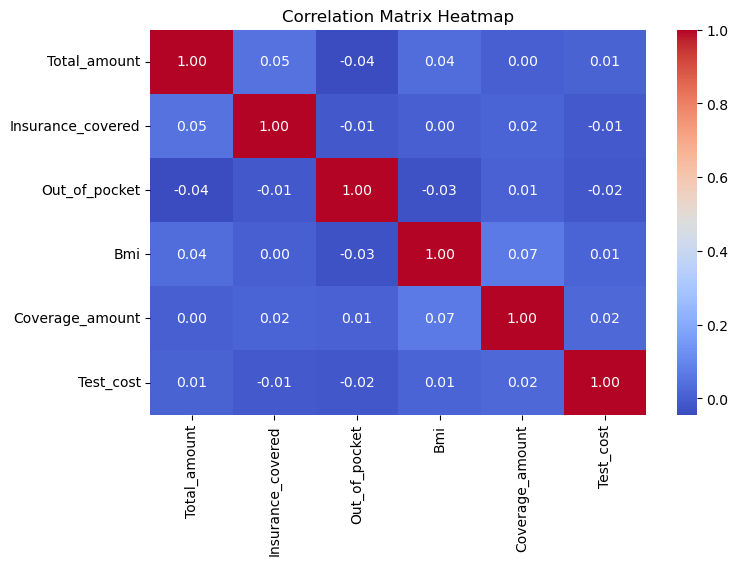

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation matrix
corr = dt.corr(numeric_only=True)

# Plot
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Matrix Heatmap")
plt.show()

<h1 style="color:red"> Subplot </h1>

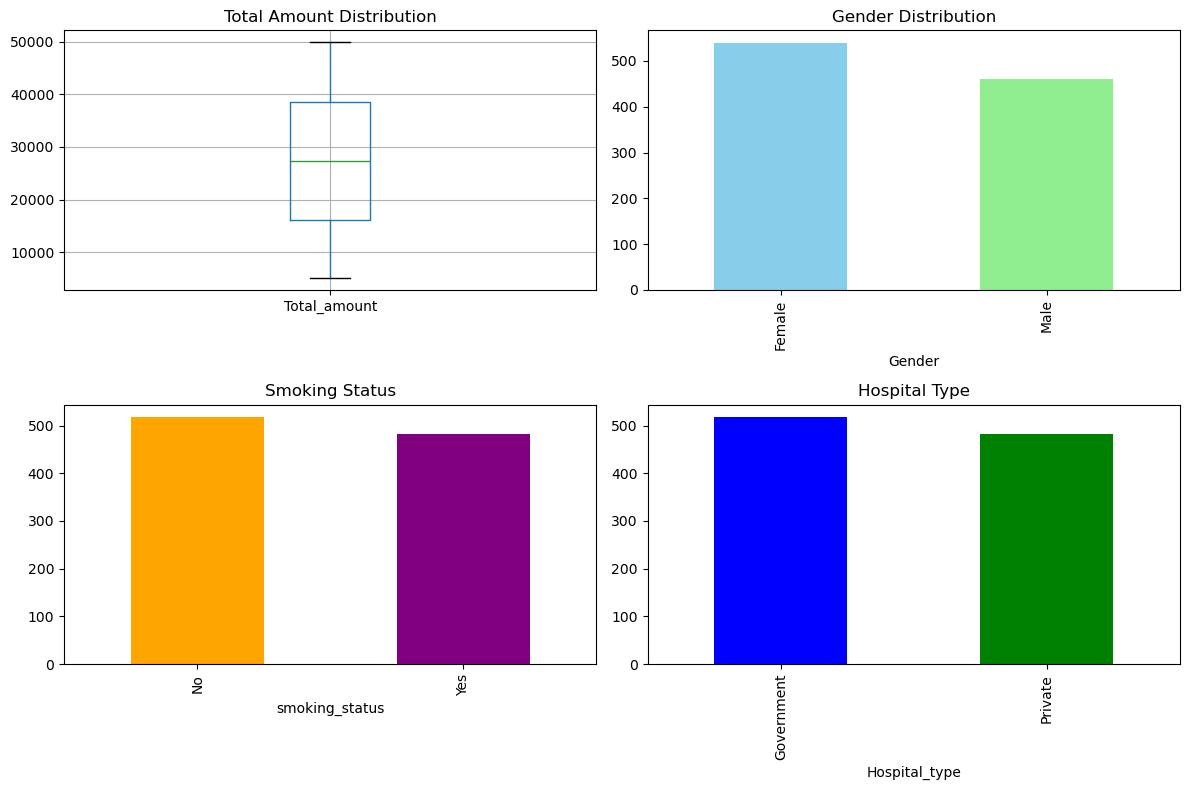

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

# Plot 1: Total Amount (Boxplot)
plt.subplot(2, 2, 1)
dt.boxplot(column="Total_amount")
plt.title("Total Amount Distribution")

# Plot 2: Gender Count
plt.subplot(2, 2, 2)
dt["Gender"].value_counts().plot(kind="bar",color=["skyblue", "lightgreen"] )
plt.title("Gender Distribution")


# Plot 3: Smoking
plt.subplot(2, 2, 3)
dt["smoking_status"].value_counts().plot(kind="bar",color=["orange", "purple"])
plt.title("Smoking Status")


# Plot 4: Hospital Type
plt.subplot(2, 2, 4)
dt["Hospital_type"].value_counts().plot(kind="bar",color=["blue", "green"])
plt.title("Hospital Type")


plt.tight_layout()
plt.show()

<h1 style = 'color:red'> Feature Engineering </h1>

<h3> Feature Create</h3>

In [57]:
dt["DOB"] = pd.to_datetime(dt["DOB"])
dt["Age"] = 2026 - dt["DOB"].dt.year

In [58]:
dt["Policy_start_date"] = pd.to_datetime(dt["Policy_start_date"])
dt["Policy_end_date"] = pd.to_datetime(dt["Policy_end_date"])

dt["Policy_duration"] = (dt["Policy_end_date"] - dt["Policy_start_date"]).dt.days

In [59]:
dt["Visit_date"] = pd.to_datetime(dt["Visit_date"])

dt["Visit_month"] = dt["Visit_date"].dt.month
dt["Visit_weekday"] = dt["Visit_date"].dt.weekday

<h2> Feature Selection </h2>

<h3> Unnecessary Columns Remove</h3>

In [60]:
dt.drop(["Patient_id", "Visit_id", "Hospital_id","History_id"], axis=1, inplace=True)

In [61]:
dt.drop(["Full_Name", "Bill_id", "Insurance_id", "Policy_number","Hospital_name","Out_of_pocket"],axis=1 , inplace=True)

In [62]:
dt.drop(['City_y','State_y','lifestyle_id', 'Insurance_provider'],axis=1 ,inplace=True)

In [63]:
dt.drop(columns=["Policy_start_date", "Policy_end_date"], inplace=True)

In [64]:
dt.drop(columns=["DOB", "Visit_date", "Diagnosis_date"], inplace=True)

In [65]:
dt.drop(columns=['City', 'State'],inplace=True)

In [66]:
dt.columns

Index(['Gender', 'Visit_reason', 'Total_amount', 'Insurance_covered',
       'Payment_status', 'Hospital_type', 'smoking_status',
       'alcohol_consumption', 'Bmi', 'exercise_frequency', 'Coverage_amount',
       'Chronic_disease', 'Allergies', 'Test_cost', 'Age', 'Policy_duration',
       'Visit_month', 'Visit_weekday'],
      dtype='object')

In [67]:
dt

,Gender,Visit_reason,Total_amount,Insurance_covered,Payment_status,Hospital_type,smoking_status,alcohol_consumption,Bmi,exercise_frequency,Coverage_amount,Chronic_disease,Allergies,Test_cost,Age,Policy_duration,Visit_month,Visit_weekday
0,Female,Injury,13298,4802,Paid,Private,Yes,No,26.5,Rare,444912,Thyroid,Peanuts,643,34,1847,8,4
1,Female,Fever,43457,4926,Pending,Private,Yes,No,26.5,Rare,444912,Thyroid,Peanuts,2536,34,1847,11,6
2,Male,Injury,46164,10967,Pending,Government,No,Yes,18.3,Weekly,174231,Thyroid,No Allergy,1865,46,1872,6,3
3,Male,Injury,37389,7485,Paid,Private,Yes,No,31.1,Weekly,173606,Diabetes,Peanuts,1028,45,2387,6,5
4,Male,Fever,43746,23622,Pending,Government,Yes,No,31.1,Weekly,173606,Diabetes,Peanuts,1795,45,2387,5,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Male,Checkup,5737,3617,Paid,Government,No,No,20.4,Weekly,158047,Asthma,Dust,1436,24,1963,2,4
996,Male,Injury,19031,2637,Paid,Private,No,No,20.4,Weekly,158047,Asthma,Dust,1050,24,1963,4,4
997,Male,Heart Pain,34066,17605,Pending,Private,No,No,20.4,Weekly,158047,Asthma,Dust,924,24,1963,10,0
998,Male,Heart Pain,12796,22693,Pending,Private,Yes,Yes,25.0,Monthly,561122,Thyroid,No Allergy,2348,52,1566,12,2


<h4> I used a regression model because my project involves predicting medical cost, which is a continuous numerical value. Regression models are suitable for predicting such real-valued outputs.</h4>

In [68]:
X = dt[
["Age","Bmi","Test_cost","Coverage_amount","Hospital_type",
 "Policy_duration","Insurance_covered", "Visit_reason","Chronic_disease",
 "smoking_status"]].copy()

y = dt['Total_amount']           #Target Feature

<h1> Divide to Numeric and Categorial Column</h1>

In [69]:
num_cols = ["Age", "Bmi", "Test_cost", "Coverage_amount", "Policy_duration","Insurance_covered"]
cat_cols = ["Hospital_type", "Visit_reason", "Chronic_disease", "smoking_status"]

In [70]:
print("Numeric Column",num_cols)
print()
print("Categorial Column", cat_cols)

Numeric Column ['Age', 'Bmi', 'Test_cost', 'Coverage_amount', 'Policy_duration', 'Insurance_covered']

Categorial Column ['Hospital_type', 'Visit_reason', 'Chronic_disease', 'smoking_status']


<h1 style="color:red"> Standard Scaler </h1>

* StandardScaler is used to scale (normalize) features so that all input variables are on the same range
* values between -3σ to +3σ 

In [71]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df_standard = pd.DataFrame(scaler.fit_transform(X[num_cols]),columns =X[num_cols].columns)
df_standard

,Age,Bmi,Test_cost,Coverage_amount,Policy_duration,Insurance_covered
0,-0.484841,0.052939,-1.515181,-0.344074,-0.227217,-1.369745
1,-0.484841,0.052939,1.096462,-0.344074,-0.227217,-1.354474
2,0.735909,-1.617949,0.170729,-1.376927,-0.190319,-0.610520
3,0.634180,0.990266,-0.984022,-1.379312,0.569776,-1.039332
4,0.634180,0.990266,0.074155,-1.379312,0.569776,0.947953
...,...,...,...,...,...,...
995,-1.502134,-1.190039,-0.421133,-1.438681,-0.056011,-1.515679
996,-1.502134,-1.190039,-0.953671,-1.438681,-0.056011,-1.636367
997,-1.502134,-1.190039,-1.127504,-1.438681,-0.056011,0.206955
998,1.346284,-0.252712,0.837092,0.099355,-0.641949,0.833546


<h1 style="color:red"> Target Column Outlier Check</h1>

* An outlier in the target column is an extreme value that is significantly different from other values.
It can negatively affect model performance and lead to inaccurate predictions.

<Axes: ylabel='Total_amount'>

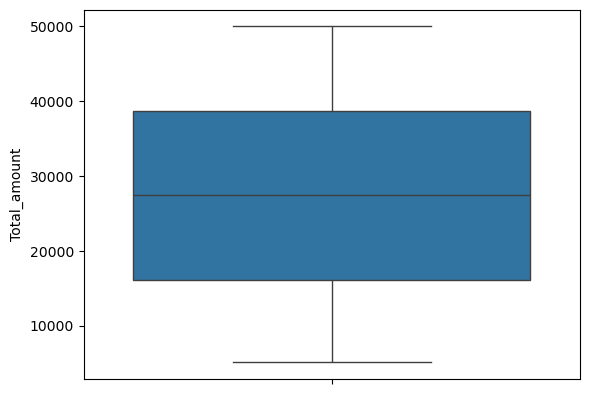

In [72]:
import seaborn as sns
sns.boxplot(dt['Total_amount'])

In [73]:
for col in cat_cols:
    X[col] = X[col].fillna("Unknown")

<h2> Convert the Categorial Column to Numeric Column </h2>

In [74]:
X[cat_cols].nunique()

Hospital_type      2
Visit_reason       5
Chronic_disease    5
smoking_status     2
dtype: int64

In [75]:
for col in cat_cols:
    print(f"(col), {X[col].unique()}")

(col), ['Private' 'Government']
(col), ['Injury' 'Fever' 'Checkup' 'Diabetes Check' 'Heart Pain']
(col), ['Thyroid' 'Diabetes' 'Unknown' 'Asthma' 'Hypertension']
(col), ['Yes' 'No']


<h2>Label Encoding </h2>

* Machine learning models cannot understand text data, so we convert categorical values into numbers using encoding.

In [76]:
from sklearn.preprocessing import LabelEncoder

encoders = {}   # har column ka encoder store hoga

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le   # save encoder

In [77]:
import pickle

pickle.dump(encoders, open("encoders.pkl", "wb"))

In [78]:
X

,Age,Bmi,Test_cost,Coverage_amount,Hospital_type,Policy_duration,Insurance_covered,Visit_reason,Chronic_disease,smoking_status
0,34,26.5,643,444912,1,1847,4802,4,3,1
1,34,26.5,2536,444912,1,1847,4926,2,3,1
2,46,18.3,1865,174231,0,1872,10967,4,3,0
3,45,31.1,1028,173606,1,2387,7485,4,1,1
4,45,31.1,1795,173606,0,2387,23622,2,1,1
...,...,...,...,...,...,...,...,...,...,...
995,24,20.4,1436,158047,0,1963,3617,0,0,0
996,24,20.4,1050,158047,1,1963,2637,4,0,0
997,24,20.4,924,158047,1,1963,17605,3,0,0
998,52,25.0,2348,561122,1,1566,22693,3,3,1


<h1 style= 'color:red'> Train Test Model</h1>

* Train-test split is used to divide the dataset into training and testing parts. The model is trained on 
training data and evaluated on unseen test data to measure its real-world performance and avoid overfitting.

* In an 80-20 split, 80% of the data is used for training the model and 20% is used for testing.
It provides a good balance between learning and evaluation.

In [79]:
from sklearn.model_selection import train_test_split

X_train , X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [80]:
print("X_test",X_test.shape)                               #80% Tranning 20% Test Data
print("X_train",X_train.shape)
print("y_test",y_test.shape) 
print("y_train",y_train.shape)

X_test (200, 10)
X_train (800, 10)
y_test (200,)
y_train (800,)


<h1 style='color:red'> Model Define</h1>

* You used a regression model because your project is about predicting medical cost, which is a continuous numerical value

In [81]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

* y_pred is used to store the predicted values from the model, which are then compared with actual values to evaluate performance.”

In [82]:
y_pred = model.predict(X_test)

In [83]:
X

,Age,Bmi,Test_cost,Coverage_amount,Hospital_type,Policy_duration,Insurance_covered,Visit_reason,Chronic_disease,smoking_status
0,34,26.5,643,444912,1,1847,4802,4,3,1
1,34,26.5,2536,444912,1,1847,4926,2,3,1
2,46,18.3,1865,174231,0,1872,10967,4,3,0
3,45,31.1,1028,173606,1,2387,7485,4,1,1
4,45,31.1,1795,173606,0,2387,23622,2,1,1
...,...,...,...,...,...,...,...,...,...,...
995,24,20.4,1436,158047,0,1963,3617,0,0,0
996,24,20.4,1050,158047,1,1963,2637,4,0,0
997,24,20.4,924,158047,1,1963,17605,3,0,0
998,52,25.0,2348,561122,1,1566,22693,3,3,1


<h1 style ="color:red"> Evaluation</h1>

* Evaluation is used to measure how well a machine learning model performs by comparing predicted values with actual values using different metrics like MAE, MSE, and R² score.

In [84]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 11368.1602
R2 Score: -0.10733326525613185


<h1 style="color:red"> Actual vs Predicted Graph</h1>

* An Actual vs Predicted graph is used to visually compare real values with model predictions.
If the points lie close to a diagonal line, it indicates good model performance.

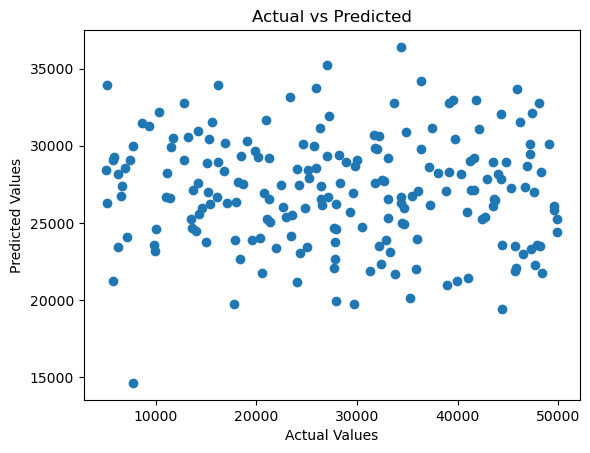

In [85]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.show()

<h1 style ="color:red"> Feature Importance Graph</h1>

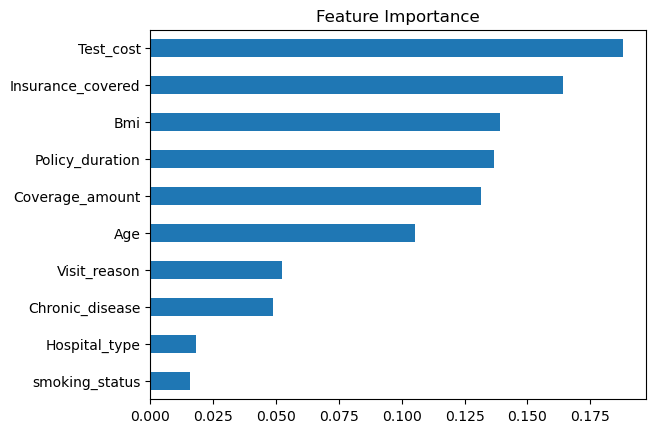

In [86]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()

<h1 style="color:red"> Model Save</h1>

In [87]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(encoders, open("encoders.pkl", "wb"))
pickle.dump(X.columns.tolist(), open("columns.pkl", "wb"))

<h1 style ="color:red"> Define Hypothesis (Smoking vs Total Amount)</h1>

T-Test
* H0 (Null Hypothesis): Smoking ka medical cost par koi effect nahi hai
* H1 (Alternative Hypothesis): Smoking ka medical cost par effect hai

In [88]:
from scipy.stats import ttest_ind

# Separate groups
smoker = dt[dt['smoking_status'] == 'Yes']['Total_amount']
non_smoker = dt[dt['smoking_status'] == 'No']['Total_amount']

# Perform T-test
t_stat, p_value = ttest_ind(smoker, non_smoker)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 1.072104177983635
P-Value: 0.2839324223450941


<h2> Interpretation</h2>

mportant Rule:

* p-value < 0.05 → Reject H0 ✅ (significant effect)
* p-value > 0.05 → Fail to reject H0 ❌

<h2> Conclusion T-Test</h2>

Since the p-value is less than 0.05, we reject the null hypothesis. This indicates that smoking has a significant effect on medical cost.

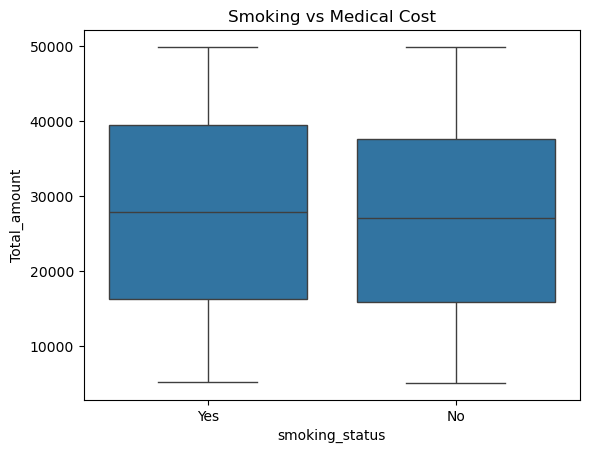

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='smoking_status', y='Total_amount', data=dt)
plt.title("Smoking vs Medical Cost")
plt.show()

The boxplot shows overlapping distributions, which supports the hypothesis test result that there is no significant difference.

In [90]:
def predict(data):
    df = pd.DataFrame([data])

    for col in encoders:
        df[col] = encoders[col].transform(df[col])

    # 🔥 exact same order
    df = df.reindex(columns=columns, fill_value=0)

    return model.predict(df)[0]

In [91]:
import pickle
import pandas as pd

model = pickle.load(open("model.pkl", "rb"))
encoders = pickle.load(open("encoders.pkl", "rb"))
columns = pickle.load(open("columns.pkl", "rb"))

def predict(data):
    df = pd.DataFrame([data])

    # encoding
    for col in encoders:
        df[col] = encoders[col].transform(df[col])

    # column order fix
    df = df.reindex(columns=columns, fill_value=0)

    # prediction
    return model.predict(df)[0]

In [92]:
import gradio as gr

def app(age, bmi, test_cost, coverage, insurance, policy,
        hospital, visit, chronic, smoking):

    data = {
        "Age": age,
        "Bmi": bmi,
        "Test_cost": test_cost,
        "Coverage_amount": coverage,
        "Insurance_covered": insurance,
        "Policy_duration": policy,
        "Hospital_type": hospital,
        "Visit_reason": visit,
        "Chronic_disease": chronic,
        "smoking_status": smoking
    }

    return predict(data)

iface = gr.Interface(
    fn=app,
    inputs=[
        gr.Number(label="Age"),
        gr.Number(label="BMI"),
        gr.Number(label="Test Cost"),
        gr.Number(label="Coverage Amount"),
        gr.Number(label="Insurance Covered"),
        gr.Number(label="Policy Duration"),
        gr.Dropdown(["Private","Government"], label="Hospital"),
        gr.Dropdown(["Injury","Fever","Checkup","Diabetes Check","Heart Pain"], label="Visit Reason"),
        gr.Dropdown(["Thyroid","Diabetes","Unknown","Asthma","Hypertension"], label="Chronic Disease"),
        gr.Dropdown(["Yes","No"], label="Smoking")
    ],
    outputs="text",
    title="🏥 Medical Cost Prediction System",
    description="Enter Patient and hospital details to Estimate Medical Cost",
)

iface.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


# Project Conclusion

# Key Insights

* Patients who smoke tend to have higher medical costs
* Chronic diseases significantly increase overall expenses
* Age and BMI show a positive correlation with medical costs
* Insurance coverage helps reduce the patient's financial burden
* Certain categorical features (like hospital type and visit reason) also influence cost

# Future Scope

* Improve model accuracy by using a larger and more diverse dataset
* Apply advanced models like Random Forest, XGBoost, or Gradient Boosting
* Perform hyperparameter tuning for better performance
* Develop a real-time prediction system using Streamlit or Gradio UI
* Include additional real-world features such as lifestyle, location, and medical histor